In [46]:
"""Классификация изображений кошек и собак с TensorFlow 2.x

Этот блокнот выполняет следующие задачи:
1. Создает тестовый набор данных: по 10 изображений каждого класса (Cat и Dog) из папки PetImages.
2. Выполняет разметку данных на основе имени папки (класс определяется по родительской директории).
3. Решает задачу классификации объектов с помощью сверточной нейронной сети (CNN).
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import zipfile
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости результатов
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")


TensorFlow version: 2.20.0
Keras version: 3.11.3


In [47]:
# ==============================================
# 1. НАСТРОЙКА ПУТЕЙ
# ==============================================

# Укажите правильный путь к вашей папке с данными
# Пример: Windows: r"C:\Users\YourName\3 курс 6 семестр\Глубокое машинное обучение\Практика 8\PetImages"
# Пример: Mac/Linux: "/Users/YourName/3 курс 6 семестр/Глубокое машинное обучение/Практика 8/PetImages"
DATA_DIR = Path("..\..\Глубокое машинное обучение\Практика 8\PetImages")  # Замените на ваш путь, если папка не в той же директории, что и блокнот

# Создаем временную папку для тестовых данных
TEST_DIR = Path("Test")
TRAIN_DIR = Path("Train")
VAL_DIR = Path("Validation")

# Проверяем, существует ли папка с данными
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Папка с данными не найдена по пути: {DATA_DIR.absolute()}\n"
                            f"Пожалуйста, проверьте путь к DATA_DIR.")

# Создаем необходимые директории
for dir_path in [TEST_DIR, TRAIN_DIR, VAL_DIR]:
    dir_path.mkdir(exist_ok=True)

print(f"✓ Директории успешно созданы: {TEST_DIR}, {TRAIN_DIR}, {VAL_DIR}")

✓ Директории успешно созданы: Test, Train, Validation


In [48]:
def is_valid_image(file_path):
    """
    Проверяет, является ли файл корректным изображением.
    """
    try:
        with Image.open(file_path) as img:
            img.verify()  # Проверяем целостность
        return True
    except Exception:
        return False

def get_valid_images(directory):
    """
    Возвращает список корректных изображений в директории.
    """
    valid_images = []
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    
    for ext in extensions:
        for img_path in directory.glob(ext):
            if is_valid_image(img_path):
                valid_images.append(img_path)
    
    return valid_images


In [49]:
# ==============================================
# 2. СОЗДАНИЕ ТЕСТОВОГО НАБОРА ДАННЫХ
# ==============================================

def create_test_set(source_dir, target_dir, samples_per_class=10):
    """
    Копирует samples_per_class валидных изображений из каждой папки класса.
    """
    classes = [d for d in source_dir.iterdir() if d.is_dir()]
    
    for class_dir in classes:
        target_class_dir = target_dir / class_dir.name
        target_class_dir.mkdir(exist_ok=True)
        
        # Получаем только валидные изображения
        valid_images = get_valid_images(class_dir)
        
        if len(valid_images) < samples_per_class:
            print(f"Предупреждение: В папке {class_dir.name} только {len(valid_images)} валидных изображений. Копируем все.")
            samples_to_copy = valid_images
        else:
            samples_to_copy = random.sample(valid_images, samples_per_class)
        
        for img_path in samples_to_copy:
            dest_path = target_class_dir / img_path.name
            shutil.copy2(img_path, dest_path)
        
        print(f"✓ Скопировано {len(samples_to_copy)} изображений из '{class_dir.name}' в {target_class_dir}")

print("\n=== СОЗДАНИЕ ТЕСТОВОГО НАБОРА ===")
create_test_set(DATA_DIR, TEST_DIR, samples_per_class=10)


=== СОЗДАНИЕ ТЕСТОВОГО НАБОРА ===
✓ Скопировано 10 изображений из 'Cat' в Test\Cat
✓ Скопировано 10 изображений из 'Dog' в Test\Dog


In [50]:
# ==============================================
# 3. РАЗМЕТКА ДАННЫХ НА ОСНОВЕ ИМЕНИ ФАЙЛА
# ==============================================

def create_dataframe_from_directory(data_dir):
    """
    Создает DataFrame только из валидных изображений.
    """
    filenames = []
    labels = []
    filepaths = []
    
    for class_dir in data_dir.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            valid_images = get_valid_images(class_dir)
            
            for img_path in valid_images:
                filepaths.append(str(img_path))
                filenames.append(img_path.name)
                labels.append(label)
    
    df = pd.DataFrame({
        'filepath': filepaths,
        'filename': filenames,
        'label': labels
    })
    return df

# Создаем DataFrame
train_df = create_dataframe_from_directory(DATA_DIR)
print(f"\n=== РАЗМЕТКА ДАННЫХ ===")
print(f"Всего валидных изображений в датасете: {len(train_df)}")
print(f"Распределение классов:\n{train_df['label'].value_counts()}")

# Разделяем на train/validation (80/20)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['label'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nТренировочных: {len(train_df)}")
print(f"Валидационных: {len(val_df)}")
print(f"Тестовых: {len(list(TEST_DIR.glob('*/*.*')))}")


=== РАЗМЕТКА ДАННЫХ ===
Всего валидных изображений в датасете: 24999
Распределение классов:
label
Cat    12500
Dog    12499
Name: count, dtype: int64

Тренировочных: 19999
Валидационных: 5000
Тестовых: 20


In [42]:
# ==============================================
# 4. ПАРАМЕТРЫ МОДЕЛИ
# ==============================================

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 2
CLASS_NAMES = sorted(train_df['label'].unique())

print(f"\n=== ПАРАМЕТРЫ ОБУЧЕНИЯ ===")
print(f"Размер изображений: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Классы: {CLASS_NAMES}")



=== ПАРАМЕТРЫ ОБУЧЕНИЯ ===
Размер изображений: (150, 150)
Batch size: 32
Классы: ['Cat', 'Dog']


In [53]:
# ==============================================
# 5. ЗАГРУЗКА ДАННЫХ С АУГМЕНТАЦИЕЙ
# ==============================================

# Data augmentation для тренировочных данных
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Только нормализация для валидационных и тестовых данных
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Создаем генераторы
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Генератор для тестовых данных
test_generator = val_test_datagen.flow_from_directory(
    directory=TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nНайдено классов: {set(train_generator.classes).__len__()}")
print(f"Индексы классов: {train_generator.class_indices}")

Found 19999 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.
Found 20 images belonging to 2 classes.

Найдено классов: 2
Индексы классов: {'Cat': 0, 'Dog': 1}


In [54]:
# ==============================================
# 6. ПОСТРОЕНИЕ МОДЕЛИ CNN
# ==============================================

def create_cnn_model(input_shape=(150, 150, 3), num_classes=2):
    """
    Создает сверточную нейронную сеть для бинарной классификации.
    """
    model = Sequential([
        # Первый сверточный блок
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),
        
        # Второй сверточный блок
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Третий сверточный блок
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Четвертый сверточный блок
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        # Полносвязная часть
        Flatten(),
        Dropout(0.5),
        Dense(512, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Создаем и компилируем модель
model = create_cnn_model()

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,634 (13.17 MB)

 Trainable params: 3,453,634 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# ==============================================
# 7. ОБУЧЕНИЕ МОДЕЛИ
# ==============================================

# Callbacks для улучшения обучения
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',  # Используем .keras вместо .h5 для TF 2.x
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\n=== НАЧАЛО ОБУЧЕНИЯ ===")
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=callbacks,
    verbose=1
)


=== НАЧАЛО ОБУЧЕНИЯ ===
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.5289 - loss: 0.6966
Epoch 1: val_accuracy improved from None to 0.63600, saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 161ms/step - accuracy: 0.5581 - loss: 0.6811 - val_accuracy: 0.6360 - val_loss: 0.6475
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6181 - loss: 0.6452
Epoch 2: val_accuracy improved from 0.63600 to 0.67520, saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.6315 - loss: 0.6369 - val_accuracy: 0.6752 - val_loss: 0.5970
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6678 - loss: 0.6079
Epoch 3: val_accuracy improved from 0.67520 to 0.67540, saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.6826 - loss: 0.5929 - val_accuracy: 0.6754 - val_loss: 0.5800
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7140 - loss: 0.560

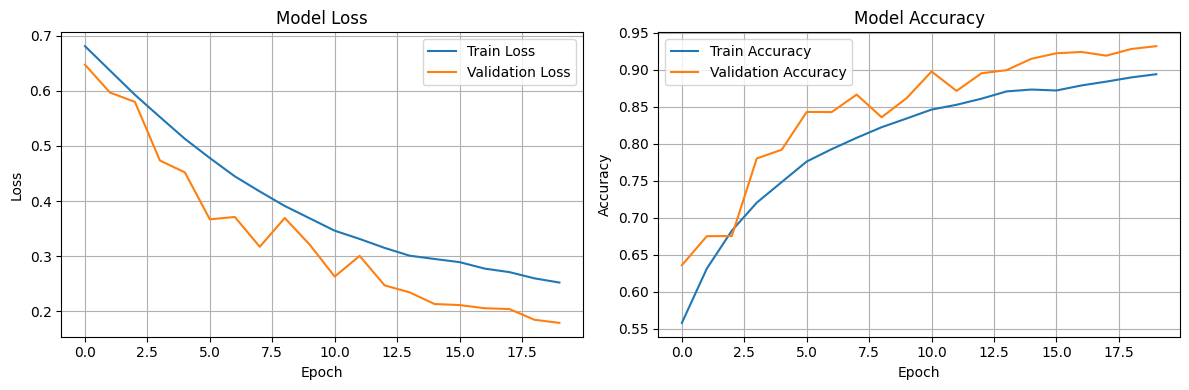

In [56]:

# ==============================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
# ==============================================

def plot_training_history(history):
    """
    Визуализирует графики потерь и точности во время обучения.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # График потерь
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # График точности
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [57]:

# ==============================================
# 9. ОЦЕНКА НА ТЕСТОВЫХ ДАННЫХ
# ==============================================

print("\n=== ОЦЕНКА НА ТЕСТОВОМ НАБОРЕ ===")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



=== ОЦЕНКА НА ТЕСТОВОМ НАБОРЕ ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9000 - loss: 0.2256
Test Loss: 0.2256
Test Accuracy: 0.9000


In [58]:

# ==============================================
# 10. СОЗДАНИЕ АРХИВА С ТЕСТОВЫМИ ДАННЫМИ
# ==============================================

def zip_test_data(test_dir, zip_name="test_data.zip"):
    """
    Архивирует тестовую директорию.
    """
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(test_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, start=os.path.dirname(test_dir))
                zipf.write(file_path, arcname)
    print(f"\n✓ Тестовые данные заархивированы в {zip_name}")
    print(f"  Размер архива: {os.path.getsize(zip_name) / 1024:.2f} KB")

zip_test_data(TEST_DIR, "test_data.zip")



✓ Тестовые данные заархивированы в test_data.zip
  Размер архива: 702.94 KB


In [ ]:
# ==============================================
# 12. СОХРАНЕНИЕ МОДЕЛИ
# ==============================================

# Сохраняем модель в формате .keras (рекомендуемый формат)
model.save("cat_dog_classifier.keras")

print("\n=== ЗАВЕРШЕНИЕ ===")
print("✓ Модель обучена и сохранена")
print("✓ Тестовые данные заархивированы в 'test_data.zip'")


=== ЗАВЕРШЕНИЕ ===
✓ Модель обучена и сохранена
✓ Тестовые данные заархивированы в 'test_data.zip'


: 